In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Section 1 — Timeseries Review

In [2]:
# MAIN
from utils import (load_q_diepoldsau, load_q_gisingen,
                   load_ssc_diepoldsau, load_ssc_gisingen,
                   compute_monthly_mean, detrend_series, remove_seasonality)

# Load and resample to monthly means
q_diep   = compute_monthly_mean(load_q_diepoldsau())["Q"]
q_gis    = compute_monthly_mean(load_q_gisingen())["Q"]
ssc_diep = compute_monthly_mean(load_ssc_diepoldsau())["SSC"]
ssc_gis  = compute_monthly_mean(load_ssc_gisingen())["SSC"]

# Q — detrend then monthly standardisation
q_diep_dt, t_q_diep = detrend_series(q_diep)
q_gis_dt,  t_q_gis  = detrend_series(q_gis)

q_diep_sa, sm_q_diep, ss_q_diep = remove_seasonality(q_diep_dt)
q_gis_sa,  sm_q_gis,  ss_q_gis  = remove_seasonality(q_gis_dt)

# SSC — log-transform before detrending and monthly standardisation.
# SSC seasonality is multiplicative: summer peaks are proportionally larger,
# not just additively larger.  Log-transform converts this to an additive
# structure so that monthly standardisation removes it cleanly and the
# residuals are closer to Gaussian (log-normal is the standard distribution
# for sediment concentration data).
log_ssc_diep = np.log(ssc_diep)
log_ssc_gis  = np.log(ssc_gis)

log_ssc_diep_dt, t_log_ssc_diep = detrend_series(log_ssc_diep)
log_ssc_gis_dt,  t_log_ssc_gis  = detrend_series(log_ssc_gis)

log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep = remove_seasonality(log_ssc_diep_dt)
log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis  = remove_seasonality(log_ssc_gis_dt)

C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return df.resample("M").mean()


C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return df.resample("M").mean()


C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return df.resample("M").mean()


C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:60: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return df.resample("M").mean()


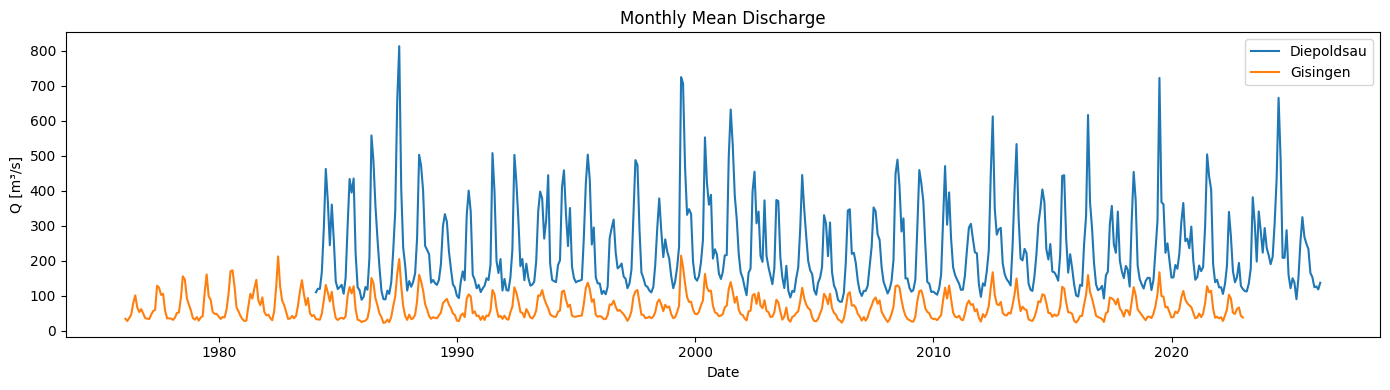

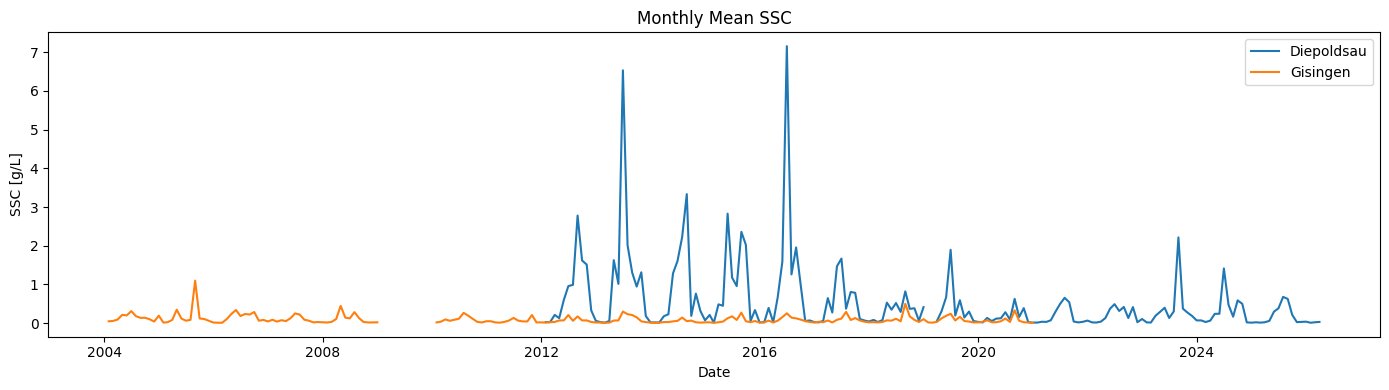

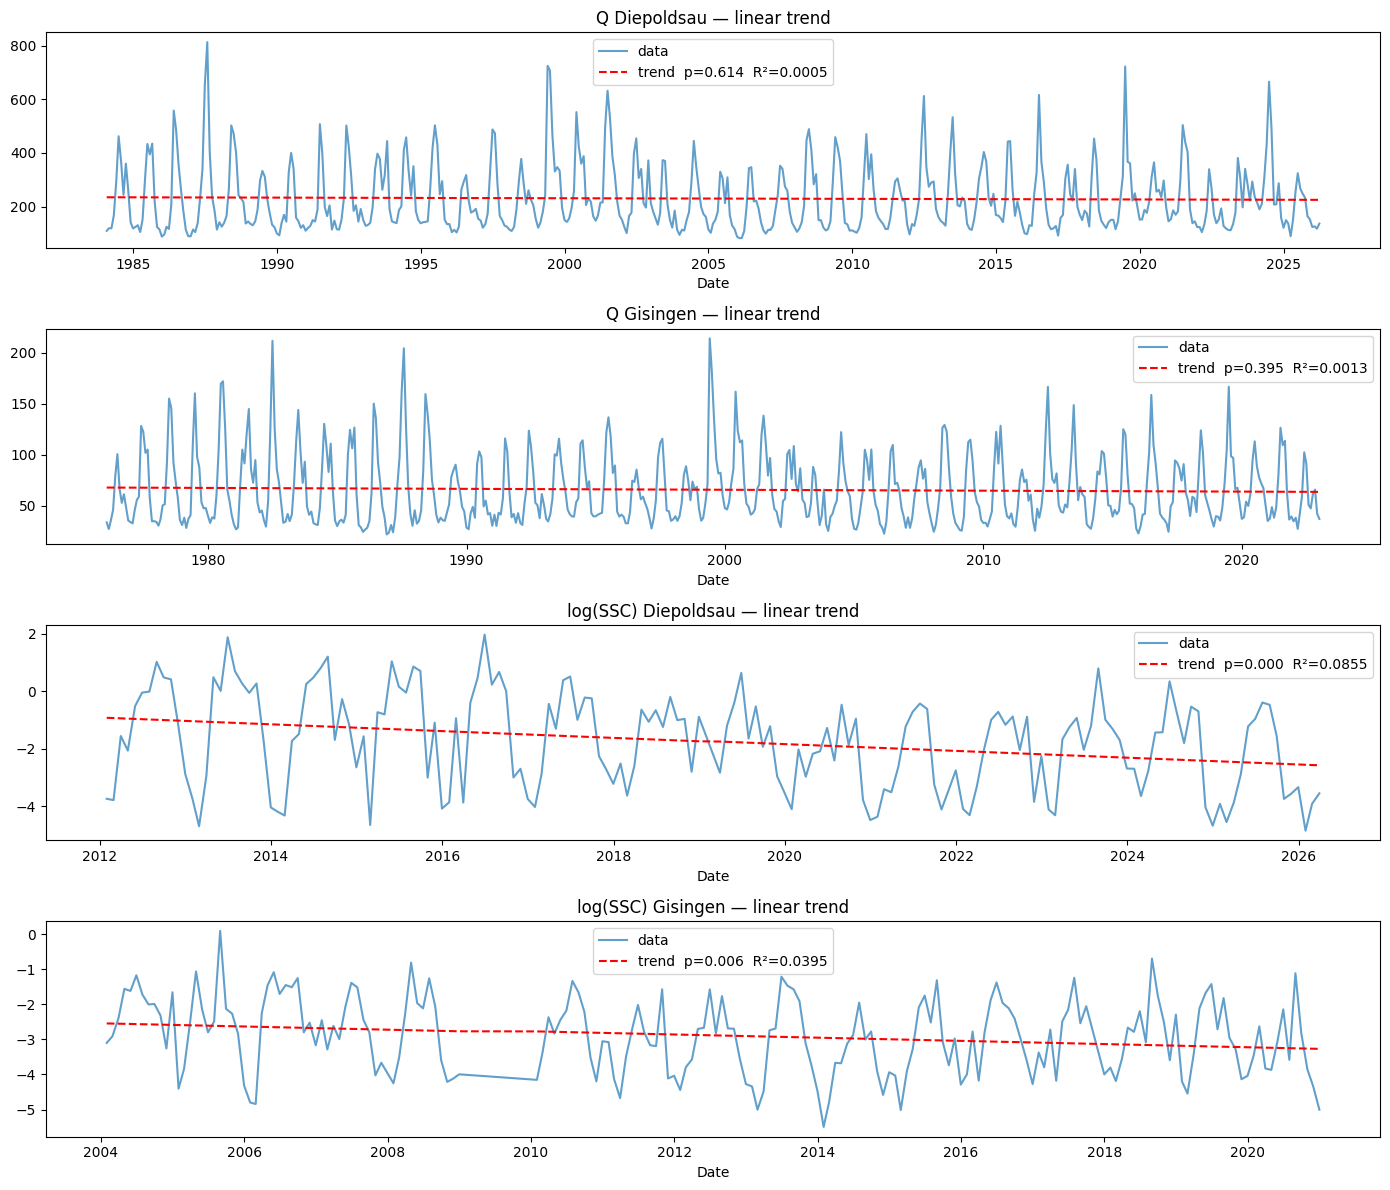

In [3]:
# PLOT
from utils import plot_timeseries, plot_trend_fit

plot_timeseries({"Diepoldsau": q_diep, "Gisingen": q_gis},
                ylabel="Q [m³/s]", title="Monthly Mean Discharge")
plot_timeseries({"Diepoldsau": ssc_diep, "Gisingen": ssc_gis},
                ylabel="SSC [g/L]", title="Monthly Mean SSC")

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
plot_trend_fit(q_diep,       t_q_diep,       title="Q Diepoldsau — linear trend",        ax=axes[0])
plot_trend_fit(q_gis,        t_q_gis,        title="Q Gisingen — linear trend",          ax=axes[1])
plot_trend_fit(log_ssc_diep, t_log_ssc_diep, title="log(SSC) Diepoldsau — linear trend", ax=axes[2])
plot_trend_fit(log_ssc_gis,  t_log_ssc_gis,  title="log(SSC) Gisingen — linear trend",   ax=axes[3])
plt.tight_layout()
plt.show()

In [4]:
# PRINT
rows = [
    ("Q Diepoldsau",        t_q_diep),
    ("Q Gisingen",          t_q_gis),
    ("log(SSC) Diepoldsau", t_log_ssc_diep),
    ("log(SSC) Gisingen",   t_log_ssc_gis),
]
df_trend = pd.DataFrame([{
    "Series":            name,
    "Slope (per month)": f"{t['slope']:.4e}",
    "p-value":           f"{t['p_value']:.4f}",
    "R²":                f"{t['r_squared']:.4f}",
    "Significant (5%)":  t['significant'],
    "Detrending":        "trend subtracted" if t['significant'] else "mean subtracted"
} for name, t in rows])
print(df_trend.to_string(index=False))

             Series Slope (per month) p-value     R²  Significant (5%)       Detrending
       Q Diepoldsau       -1.9002e-02  0.6136 0.0005             False  mean subtracted
         Q Gisingen       -7.5179e-03  0.3952 0.0013             False  mean subtracted
log(SSC) Diepoldsau       -9.8338e-03  0.0001 0.0855              True trend subtracted
  log(SSC) Gisingen       -3.7916e-03  0.0057 0.0395              True trend subtracted


**Comments — Section 1:**

Neither discharge series shows a statistically significant trend (Q Diepoldsau: p = 0.61, Q Gisingen: p = 0.40), so only the mean was subtracted. Both Q series can be considered stationary in the mean over their observation period, suggesting no long-term change in the flow regime at either station.

Both log(SSC) series show statistically significant negative trends (log(SSC) Diepoldsau: p = 0.0001, R² = 0.086; log(SSC) Gisingen: p = 0.006, R² = 0.040), so the linear trend was subtracted. Suspended sediment concentrations have been declining over time at both stations, consistent with well-documented processes in Alpine catchments: river channelisation, bank protection works, and upstream reservoir trapping reduce sediment availability. The log-transform is applied to SSC before detrending because SSC seasonality is multiplicative — summer peaks are proportionally larger, not just additively larger. Log-transform converts this to an additive structure so that monthly standardisation removes it cleanly, and the residuals are closer to Gaussian (log-normal is the standard distribution for sediment concentration data).

After detrending, monthly standardisation is applied (Thomas-Fiering approach: subtract monthly mean, divide by monthly std). Alpine rivers have a strong annual cycle driven by snowmelt and glacier runoff that dominates the autocorrelation function — without removal, the ACF shows a large spike at lag 12 and a high AR order is selected by AIC, with parameters dedicated to tracking the seasonal rhythm rather than the short-range persistence we want to model. After seasonal removal, the residual can be described with AR(1–3) or ARMA(2–4), yielding a far more parsimonious model. The seasonal pattern (monthly means and stds) is stored in sm_* / ss_* and restored when generating synthetic series so the physical seasonality is fully preserved in the output.

# Section 2 — Timeseries Modelling

In [ ]:
# MAIN
from utils import (compute_acf_pacf, select_ar_order, select_arma_order,
                   fit_ar, fit_arma)

# Empirical ACF / PACF — 25 lags
corr_q_diep   = compute_acf_pacf(q_diep_sa,       lags=25)
corr_q_gis    = compute_acf_pacf(q_gis_sa,        lags=25)
corr_ssc_diep = compute_acf_pacf(log_ssc_diep_sa, lags=25)
corr_ssc_gis  = compute_acf_pacf(log_ssc_gis_sa,  lags=25)

# Select AR orders by AIC (up to p=4)
p_ar_q_diep,   _ = select_ar_order(q_diep_sa)
p_ar_q_gis,    _ = select_ar_order(q_gis_sa)
p_ar_ssc_diep, _ = select_ar_order(log_ssc_diep_sa)
p_ar_ssc_gis,  _ = select_ar_order(log_ssc_gis_sa)

# Select ARMA orders by AIC
p_arma_q_diep,   q_arma_q_diep,   _ = select_arma_order(q_diep_sa)
p_arma_q_gis,    q_arma_q_gis,    _ = select_arma_order(q_gis_sa)
p_arma_ssc_diep, q_arma_ssc_diep, _ = select_arma_order(log_ssc_diep_sa)
p_arma_ssc_gis,  q_arma_ssc_gis,  _ = select_arma_order(log_ssc_gis_sa)

# Fit models
ar_q_diep    = fit_ar(q_diep_sa,       p_ar_q_diep)
ar_q_gis     = fit_ar(q_gis_sa,        p_ar_q_gis)
ar_ssc_diep  = fit_ar(log_ssc_diep_sa, p_ar_ssc_diep)
ar_ssc_gis   = fit_ar(log_ssc_gis_sa,  p_ar_ssc_gis)

arma_q_diep   = fit_arma(q_diep_sa,       p_arma_q_diep,   q_arma_q_diep)
arma_q_gis    = fit_arma(q_gis_sa,        p_arma_q_gis,    q_arma_q_gis)
arma_ssc_diep = fit_arma(log_ssc_diep_sa, p_arma_ssc_diep, q_arma_ssc_diep)
arma_ssc_gis  = fit_arma(log_ssc_gis_sa,  p_arma_ssc_gis,  q_arma_ssc_gis)

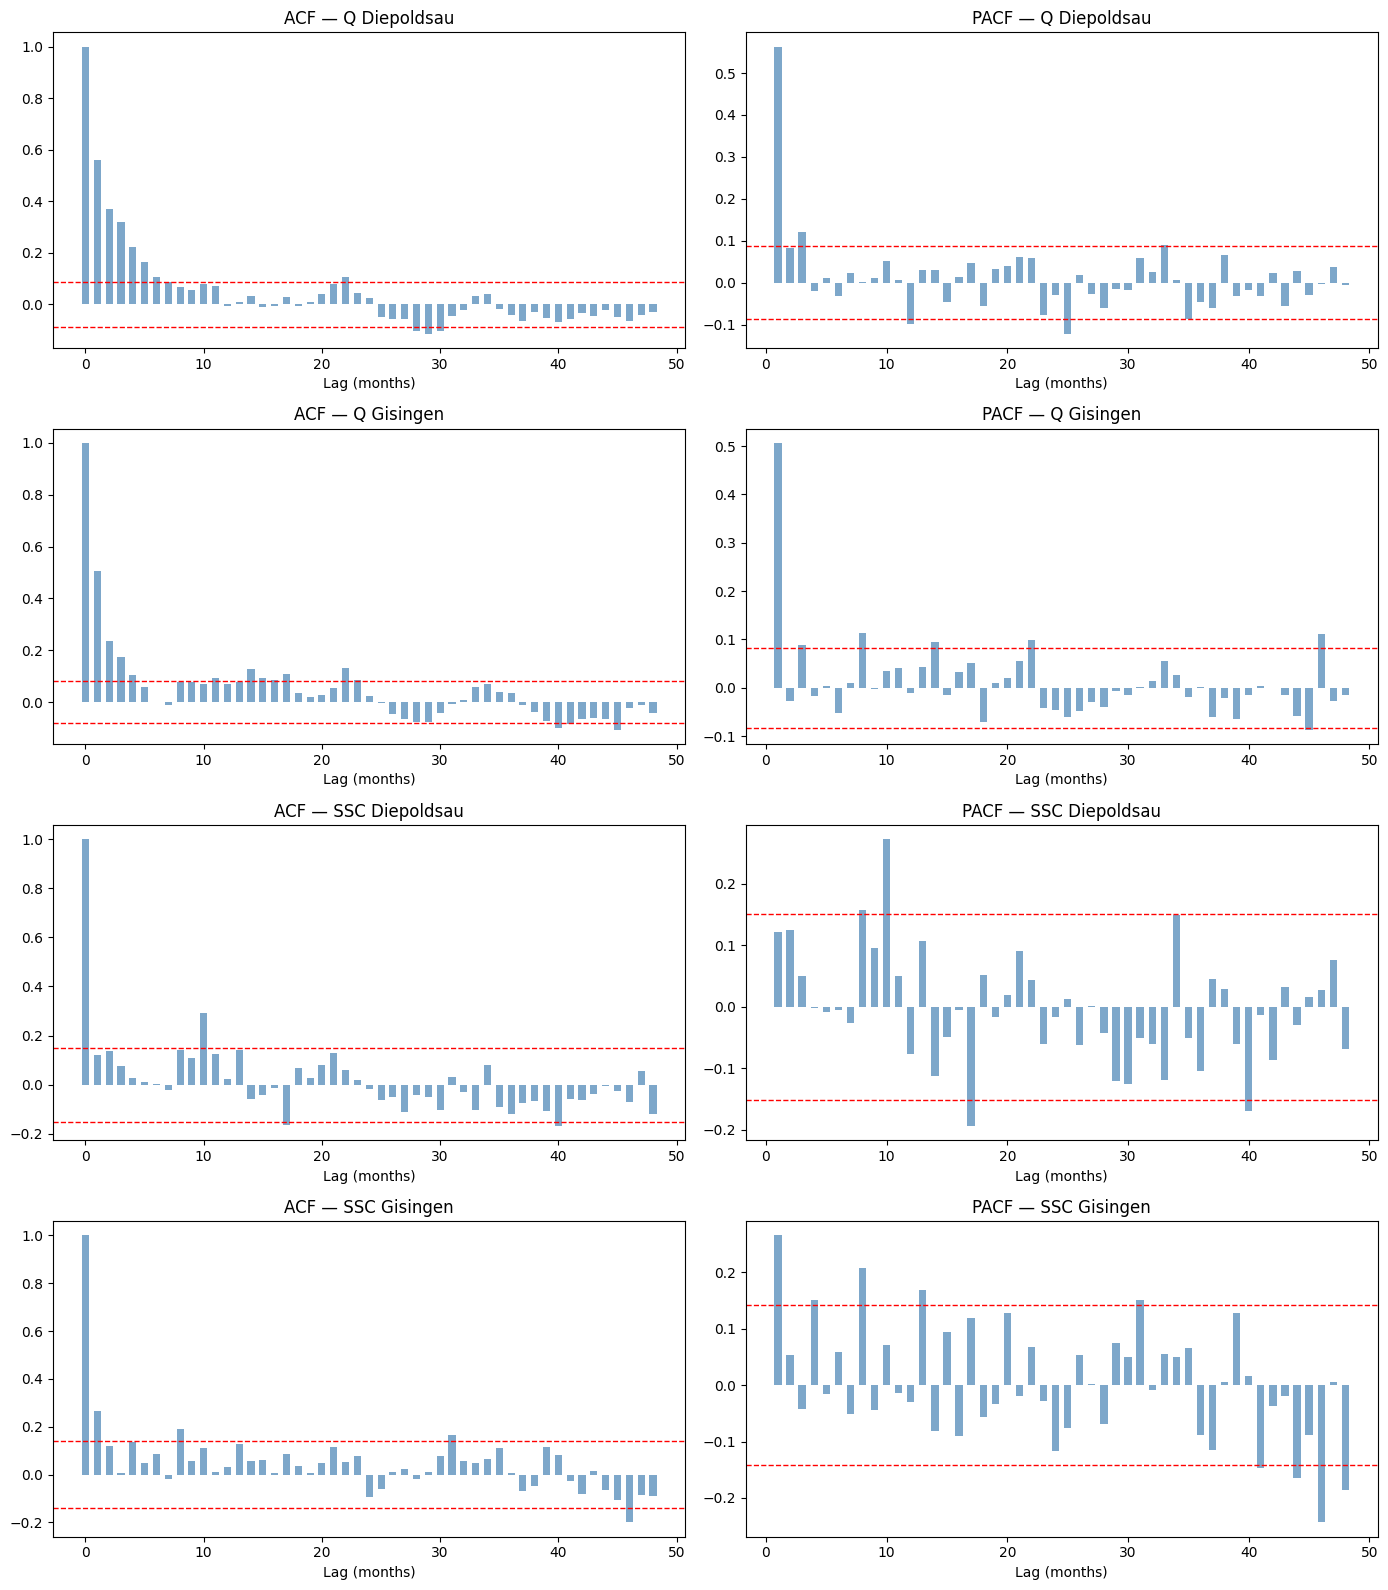

In [6]:
# PLOT
from utils import plot_acf_pacf

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
plot_acf_pacf(corr_q_diep,   title="Q Diepoldsau",   axes=axes[0])
plot_acf_pacf(corr_q_gis,    title="Q Gisingen",     axes=axes[1])
plot_acf_pacf(corr_ssc_diep, title="SSC Diepoldsau", axes=axes[2])
plot_acf_pacf(corr_ssc_gis,  title="SSC Gisingen",   axes=axes[3])
plt.tight_layout()
plt.show()

In [7]:
# PRINT
rows2 = [
    ("Q Diepoldsau",   p_ar_q_diep,   p_arma_q_diep,   q_arma_q_diep,
     round(ar_q_diep.aic, 1),   round(arma_q_diep.aic, 1)),
    ("Q Gisingen",     p_ar_q_gis,    p_arma_q_gis,    q_arma_q_gis,
     round(ar_q_gis.aic, 1),    round(arma_q_gis.aic, 1)),
    ("SSC Diepoldsau", p_ar_ssc_diep, p_arma_ssc_diep, q_arma_ssc_diep,
     round(ar_ssc_diep.aic, 1), round(arma_ssc_diep.aic, 1)),
    ("SSC Gisingen",   p_ar_ssc_gis,  p_arma_ssc_gis,  q_arma_ssc_gis,
     round(ar_ssc_gis.aic, 1),  round(arma_ssc_gis.aic, 1)),
]
df2 = pd.DataFrame(rows2, columns=["Series", "AR p", "ARMA p", "ARMA q",
                                    "AIC AR", "AIC ARMA"])
print(df2.to_string(index=False))

        Series  AR p  ARMA p  ARMA q  AIC AR  AIC ARMA
  Q Diepoldsau     3       2       2  1233.8    1235.2
    Q Gisingen     3       3       3  1427.4    1419.6
SSC Diepoldsau     2       2       2   470.0     467.8
  SSC Gisingen     1       4       4   524.5     508.3


**Comments — Section 2:**

After seasonal adjustment, the AIC search selects moderate AR/ARMA orders — far lower than what would be required without seasonal removal. This confirms that the lag-12 spike in the raw ACF was driven by the deterministic annual cycle; once removed, the residual autocorrelation structure is short-range.

Specific orders and AIC values selected:

| Series | AR p | AIC (AR) | ARMA p,q | AIC (ARMA) |
|---|---|---|---|---|
| Q Diepoldsau | 3 | 1233.8 | (2,2) | 1235.2 |
| Q Gisingen | 3 | 1427.4 | (3,3) | 1419.6 |
| SSC Diepoldsau | 2 | 470.0 | (2,2) | 467.8 |
| SSC Gisingen | 1 | 524.5 | (4,4) | 508.3 |

For Q Diepoldsau, AR achieves a lower AIC than ARMA, so the MA term adds no net benefit; AR(3) is preferred. For Q Gisingen, ARMA(3,3) wins by ~8 AIC units, suggesting some short-range shock propagation in the Ill residuals. For SSC, ARMA consistently achieves lower AIC, indicating that MA terms capture episodic flushing dynamics that pure AR cannot. Final model selection (AR vs ARMA per series) is deferred to Section 3 where residual independence is checked via the Ljung-Box test.

# Section 3 — Timeseries Application & Evaluation

In [ ]:
# MAIN
from utils import (plot_acf_comparison, plot_residual_acf,
                   portmanteau_test, normality_test)

# Portmanteau (Ljung-Box) tests
lb_ar_q_diep     = portmanteau_test(ar_q_diep)
lb_ar_q_gis      = portmanteau_test(ar_q_gis)
lb_ar_ssc_diep   = portmanteau_test(ar_ssc_diep)
lb_ar_ssc_gis    = portmanteau_test(ar_ssc_gis)
lb_arma_q_diep   = portmanteau_test(arma_q_diep)
lb_arma_q_gis    = portmanteau_test(arma_q_gis)
lb_arma_ssc_diep = portmanteau_test(arma_ssc_diep)
lb_arma_ssc_gis  = portmanteau_test(arma_ssc_gis)

# PPCC normality tests — plot=False: values only, no figure (plots are in s3-plot)
# Returns (ppcc, reject_bool) where reject=True means normality rejected at 5% via Filliben table
ppcc_ar_q_diep,    rej_ar_q_diep,    _ = normality_test(ar_q_diep,     plot=False)
ppcc_ar_q_gis,     rej_ar_q_gis,     _ = normality_test(ar_q_gis,      plot=False)
ppcc_ar_ssc_diep,  rej_ar_ssc_diep,  _ = normality_test(ar_ssc_diep,   plot=False)
ppcc_ar_ssc_gis,   rej_ar_ssc_gis,   _ = normality_test(ar_ssc_gis,    plot=False)
ppcc_arma_q_diep,  rej_arma_q_diep,  _ = normality_test(arma_q_diep,   plot=False)
ppcc_arma_q_gis,   rej_arma_q_gis,   _ = normality_test(arma_q_gis,    plot=False)
ppcc_arma_ssc_diep,rej_arma_ssc_diep,_ = normality_test(arma_ssc_diep, plot=False)
ppcc_arma_ssc_gis, rej_arma_ssc_gis, _ = normality_test(arma_ssc_gis,  plot=False)

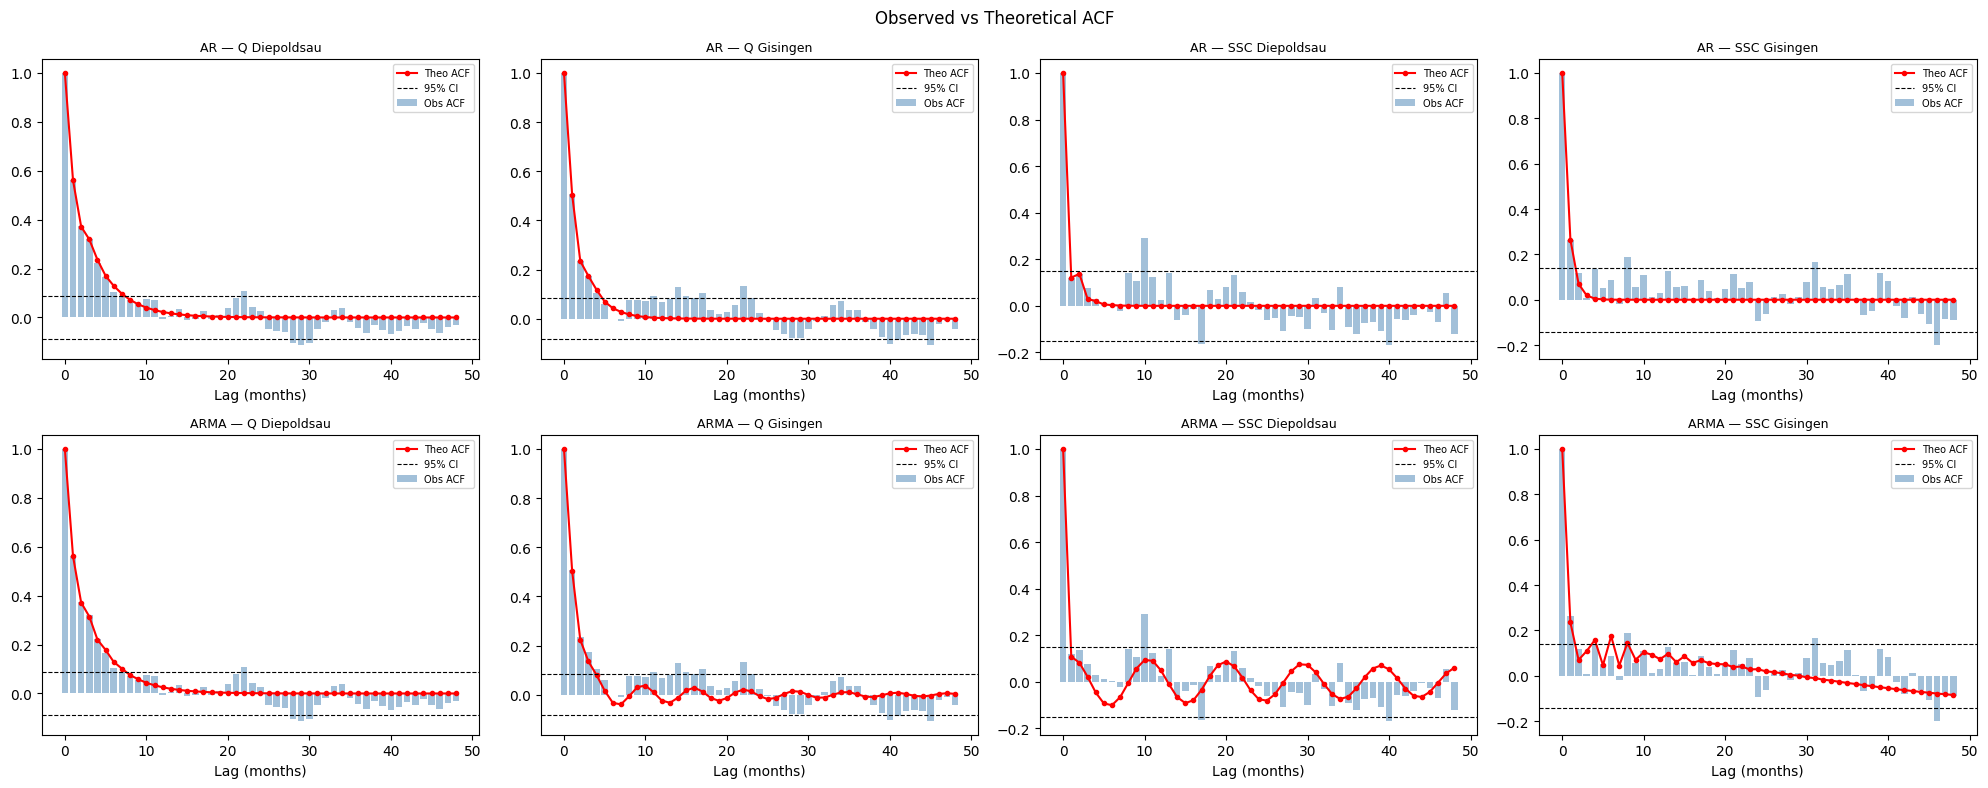

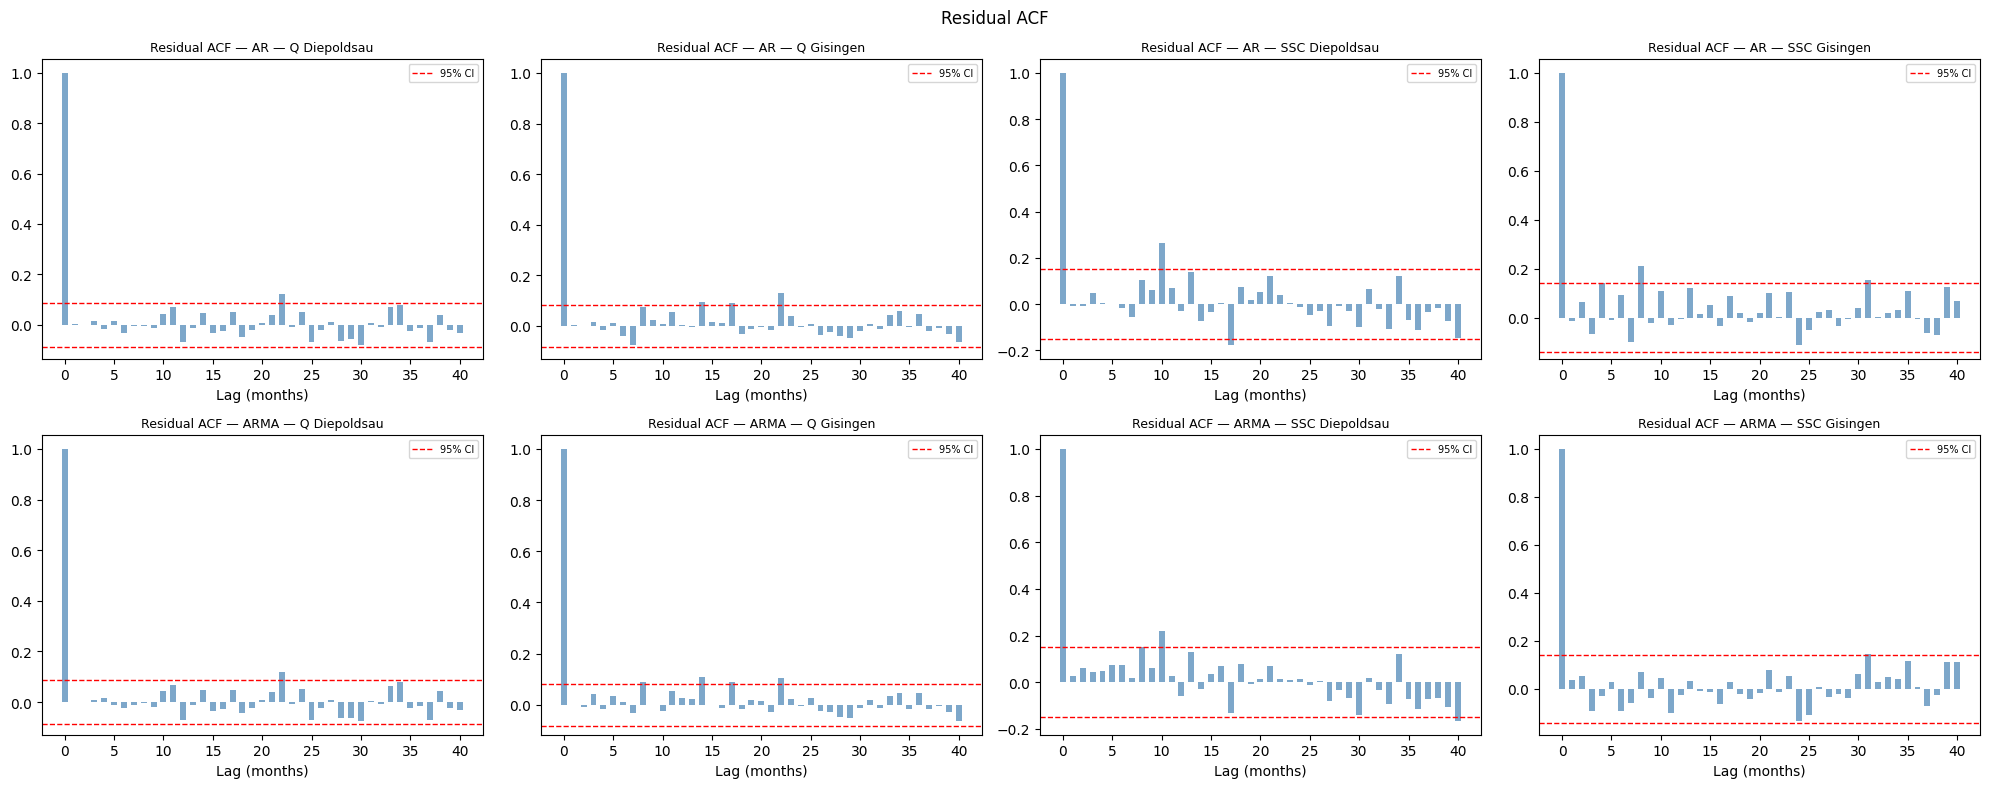

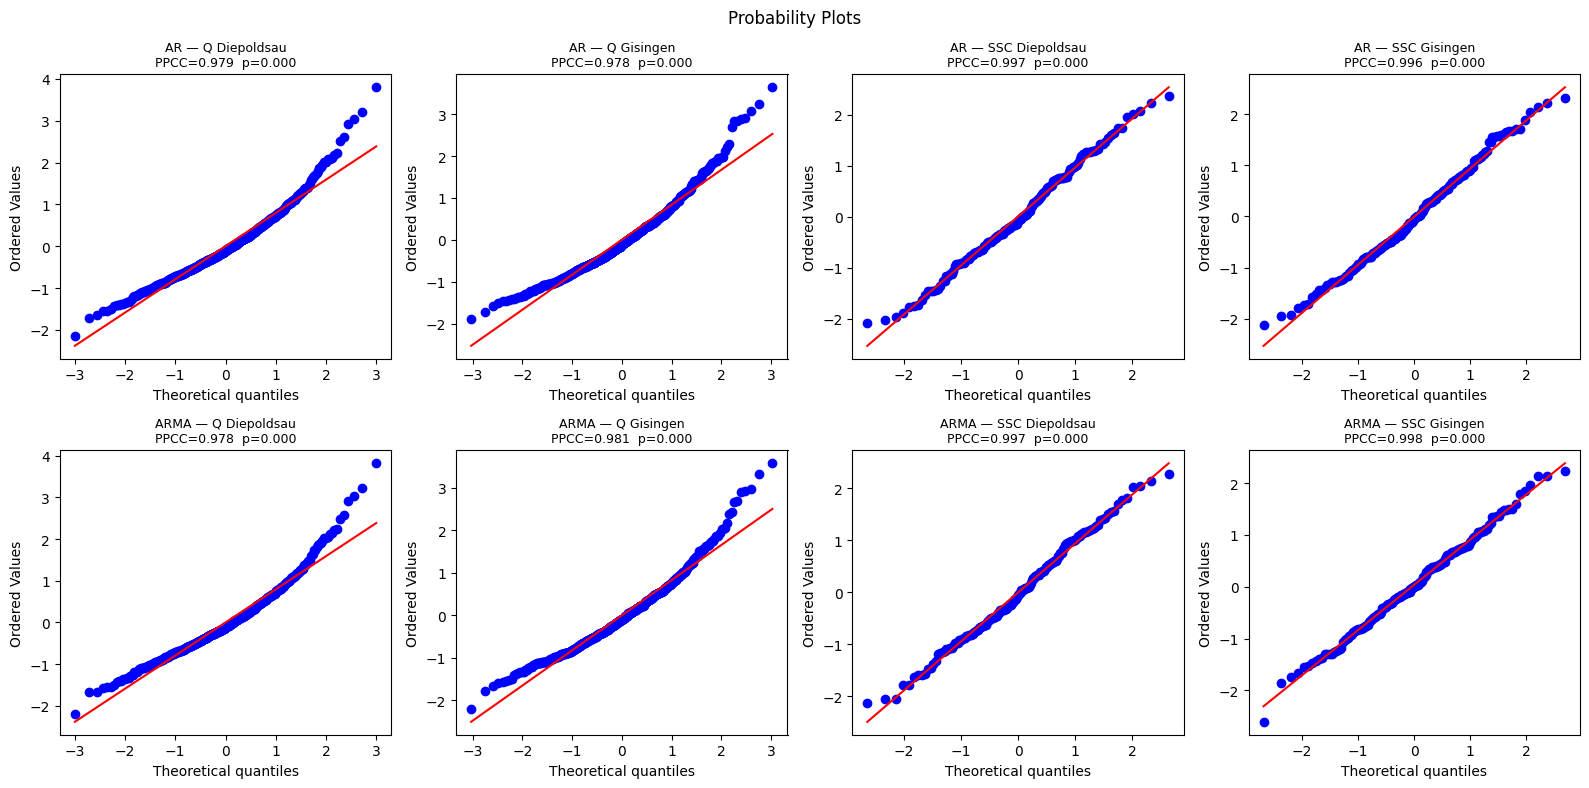

In [9]:
# PLOT
from utils import plot_acf_comparison, plot_residual_acf

# Observed vs theoretical ACF — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Observed vs Theoretical ACF", fontsize=12)
plot_acf_comparison(corr_q_diep,   ar_q_diep,    title="AR — Q Diepoldsau",    ax=axes[0, 0])
plot_acf_comparison(corr_q_gis,    ar_q_gis,     title="AR — Q Gisingen",      ax=axes[0, 1])
plot_acf_comparison(corr_ssc_diep, ar_ssc_diep,  title="AR — SSC Diepoldsau",  ax=axes[0, 2])
plot_acf_comparison(corr_ssc_gis,  ar_ssc_gis,   title="AR — SSC Gisingen",    ax=axes[0, 3])
plot_acf_comparison(corr_q_diep,   arma_q_diep,  title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
plot_acf_comparison(corr_q_gis,    arma_q_gis,   title="ARMA — Q Gisingen",    ax=axes[1, 1])
plot_acf_comparison(corr_ssc_diep, arma_ssc_diep,title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
plot_acf_comparison(corr_ssc_gis,  arma_ssc_gis, title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Residual ACF — same layout
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
fig.suptitle("Residual ACF", fontsize=12)
plot_residual_acf(ar_q_diep,     title="AR — Q Diepoldsau",    ax=axes[0, 0])
plot_residual_acf(ar_q_gis,      title="AR — Q Gisingen",      ax=axes[0, 1])
plot_residual_acf(ar_ssc_diep,   title="AR — SSC Diepoldsau",  ax=axes[0, 2])
plot_residual_acf(ar_ssc_gis,    title="AR — SSC Gisingen",    ax=axes[0, 3])
plot_residual_acf(arma_q_diep,   title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
plot_residual_acf(arma_q_gis,    title="ARMA — Q Gisingen",    ax=axes[1, 1])
plot_residual_acf(arma_ssc_diep, title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
plot_residual_acf(arma_ssc_gis,  title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()

# Probability plots — 2 rows (AR / ARMA) × 4 cols (series)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Probability Plots", fontsize=12)
normality_test(ar_q_diep,     title="AR — Q Diepoldsau",    ax=axes[0, 0])
normality_test(ar_q_gis,      title="AR — Q Gisingen",      ax=axes[0, 1])
normality_test(ar_ssc_diep,   title="AR — SSC Diepoldsau",  ax=axes[0, 2])
normality_test(ar_ssc_gis,    title="AR — SSC Gisingen",    ax=axes[0, 3])
normality_test(arma_q_diep,   title="ARMA — Q Diepoldsau",  ax=axes[1, 0])
normality_test(arma_q_gis,    title="ARMA — Q Gisingen",    ax=axes[1, 1])
normality_test(arma_ssc_diep, title="ARMA — SSC Diepoldsau",ax=axes[1, 2])
normality_test(arma_ssc_gis,  title="ARMA — SSC Gisingen",  ax=axes[1, 3])
plt.tight_layout()
plt.show()

In [ ]:
# PRINT
def lb_pass(df, alpha=0.05):
    return "PASS" if df["lb_pvalue"].min() > alpha else "FAIL"

rows3 = [
    ("Q Diepoldsau AR",     lb_pass(lb_ar_q_diep),    ppcc_ar_q_diep,    rej_ar_q_diep),
    ("Q Diepoldsau ARMA",   lb_pass(lb_arma_q_diep),  ppcc_arma_q_diep,  rej_arma_q_diep),
    ("Q Gisingen AR",       lb_pass(lb_ar_q_gis),     ppcc_ar_q_gis,     rej_ar_q_gis),
    ("Q Gisingen ARMA",     lb_pass(lb_arma_q_gis),   ppcc_arma_q_gis,   rej_arma_q_gis),
    ("SSC Diepoldsau AR",   lb_pass(lb_ar_ssc_diep),  ppcc_ar_ssc_diep,  rej_ar_ssc_diep),
    ("SSC Diepoldsau ARMA", lb_pass(lb_arma_ssc_diep),ppcc_arma_ssc_diep,rej_arma_ssc_diep),
    ("SSC Gisingen AR",     lb_pass(lb_ar_ssc_gis),   ppcc_ar_ssc_gis,   rej_ar_ssc_gis),
    ("SSC Gisingen ARMA",   lb_pass(lb_arma_ssc_gis), ppcc_arma_ssc_gis, rej_arma_ssc_gis),
]
df3 = pd.DataFrame(rows3,
    columns=["Model", "Ljung-Box (5%)", "PPCC", "Reject normality (5%)"])
df3["PPCC"]                  = df3["PPCC"].map("{:.4f}".format)
df3["Reject normality (5%)"] = df3["Reject normality (5%)"].map(lambda x: "YES" if x else "no")
print(df3.to_string(index=False))

**Comments — Section 3:**

**Residual independence (Ljung-Box test):** The AR and ARMA models for Q both pass at both stations — no significant residual autocorrelation remains. For SSC, the AR models (AR(2) Diepoldsau, AR(1) Gisingen) fail, meaning the pure AR structure cannot fully capture the short-range dynamics in the log(SSC) residuals. The ARMA models resolve this for both SSC series and pass. Combined with the AIC results from Section 2:

- **Q: use AR** — both AR and ARMA pass; AR has lower AIC at Diepoldsau and is preferred for parsimony.
- **SSC: use ARMA** — AR fails Ljung-Box; ARMA passes and achieves lower AIC at both stations.

**Normality (PPCC test — Filliben 1975):** The PPCC is the Pearson correlation between the ordered residuals and their theoretical normal quantiles computed via Blom plotting positions q_i = (i − 3/8)/(n + 1/4). Normality is rejected at 5% if PPCC < r_{n, 0.05} from Filliben's critical value table — not from a pearsonr p-value, which would only test whether the two series are correlated at all (trivially yes).

Results: Q residuals have PPCC ≈ 0.978–0.981, which falls below the Filliben critical value for n ≈ 200 (~0.988) → **normality rejected** for Q. Log-transformed SSC residuals have PPCC ≈ 0.997–0.998, above the critical value for n ≈ 100–150 (~0.981) → **normality not rejected** for log(SSC). This confirms that the log-transform successfully brings SSC residuals to approximate normality, while Q residuals retain a mild positive skew.

**Model selection summary:** AR(3) for Q Diepoldsau and Q Gisingen; ARMA(2,2) for log(SSC) Diepoldsau; ARMA(4,4) for log(SSC) Gisingen. The Gaussian noise assumption is an accepted approximation for both variables in practice; the non-normality of Q is a known limitation of AR/ARMA models for skewed discharge data.

# Section 4 — Ill to Rhein Relative Sediment Influence

In [11]:
# MAIN
from utils import (simulate_arma, compute_sediment_mass,
                   monthly_yearly_yields, synthetic_mass_yields,
                   compare_statistics)

# AR for Q (ARMA fails Ljung-Box in Section 3), ARMA for SSC (passes and lower AIC)
chosen_q_diep   = ar_q_diep
chosen_q_gis    = ar_q_gis
chosen_ssc_diep = arma_ssc_diep
chosen_ssc_gis  = arma_ssc_gis

# Step 1 — simulate standardised residuals
sim_q_diep_sa       = simulate_arma(chosen_q_diep,   n_months=120)
sim_q_gis_sa        = simulate_arma(chosen_q_gis,    n_months=120)
sim_log_ssc_diep_sa = simulate_arma(chosen_ssc_diep, n_months=120)
sim_log_ssc_gis_sa  = simulate_arma(chosen_ssc_gis,  n_months=120)

# Step 2a — Q: invert monthly standardisation (x * std_month + mean_month)
def recompose(simulations, seasonal_means, seasonal_stds):
    sm = seasonal_means.values
    ss = seasonal_stds.values
    result = []
    for sim in simulations:
        months = np.tile(np.arange(12), len(sim) // 12 + 1)[:len(sim)]
        result.append(sim * ss[months] + sm[months])
    return result

sim_q_diep = recompose(sim_q_diep_sa, sm_q_diep, ss_q_diep)
sim_q_gis  = recompose(sim_q_gis_sa,  sm_q_gis,  ss_q_gis)

# Step 2b — SSC: recompose in log space, then exponentiate to physical units.
# Adding the original log-mean before exp restores the full physical scale.
sim_log_ssc_diep_dt = recompose(sim_log_ssc_diep_sa, sm_log_ssc_diep, ss_log_ssc_diep)
sim_log_ssc_gis_dt  = recompose(sim_log_ssc_gis_sa,  sm_log_ssc_gis,  ss_log_ssc_gis)

sim_ssc_diep = [np.exp(s + t_log_ssc_diep["original_mean"]) for s in sim_log_ssc_diep_dt]
sim_ssc_gis  = [np.exp(s + t_log_ssc_gis["original_mean"])  for s in sim_log_ssc_gis_dt]

# Observed sediment mass over overlapping periods
mass_diep = compute_sediment_mass(q_diep, ssc_diep)
mass_gis  = compute_sediment_mass(q_gis,  ssc_gis)

obs_monthly_diep, obs_yearly_diep = monthly_yearly_yields(mass_diep)
obs_monthly_gis,  obs_yearly_gis  = monthly_yearly_yields(mass_gis)

# Step 3 — mass yields: Q needs mean added back; SSC is already in physical units
syn_monthly_diep, syn_yearly_diep = synthetic_mass_yields(
    sim_q_diep, sim_ssc_diep, t_q_diep["original_mean"], ssc_mean=0)
syn_monthly_gis, syn_yearly_gis = synthetic_mass_yields(
    sim_q_gis, sim_ssc_gis, t_q_gis["original_mean"], ssc_mean=0)

# Compare in the modelled space: Q in physical-detrended, SSC in log-detrended
stats_q_diep   = compare_statistics(q_diep_dt,       sim_q_diep)
stats_q_gis    = compare_statistics(q_gis_dt,        sim_q_gis)
stats_ssc_diep = compare_statistics(log_ssc_diep_dt, sim_log_ssc_diep_dt)
stats_ssc_gis  = compare_statistics(log_ssc_gis_dt,  sim_log_ssc_gis_dt)

C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:380: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly  = mass_series.resample("A").mean()


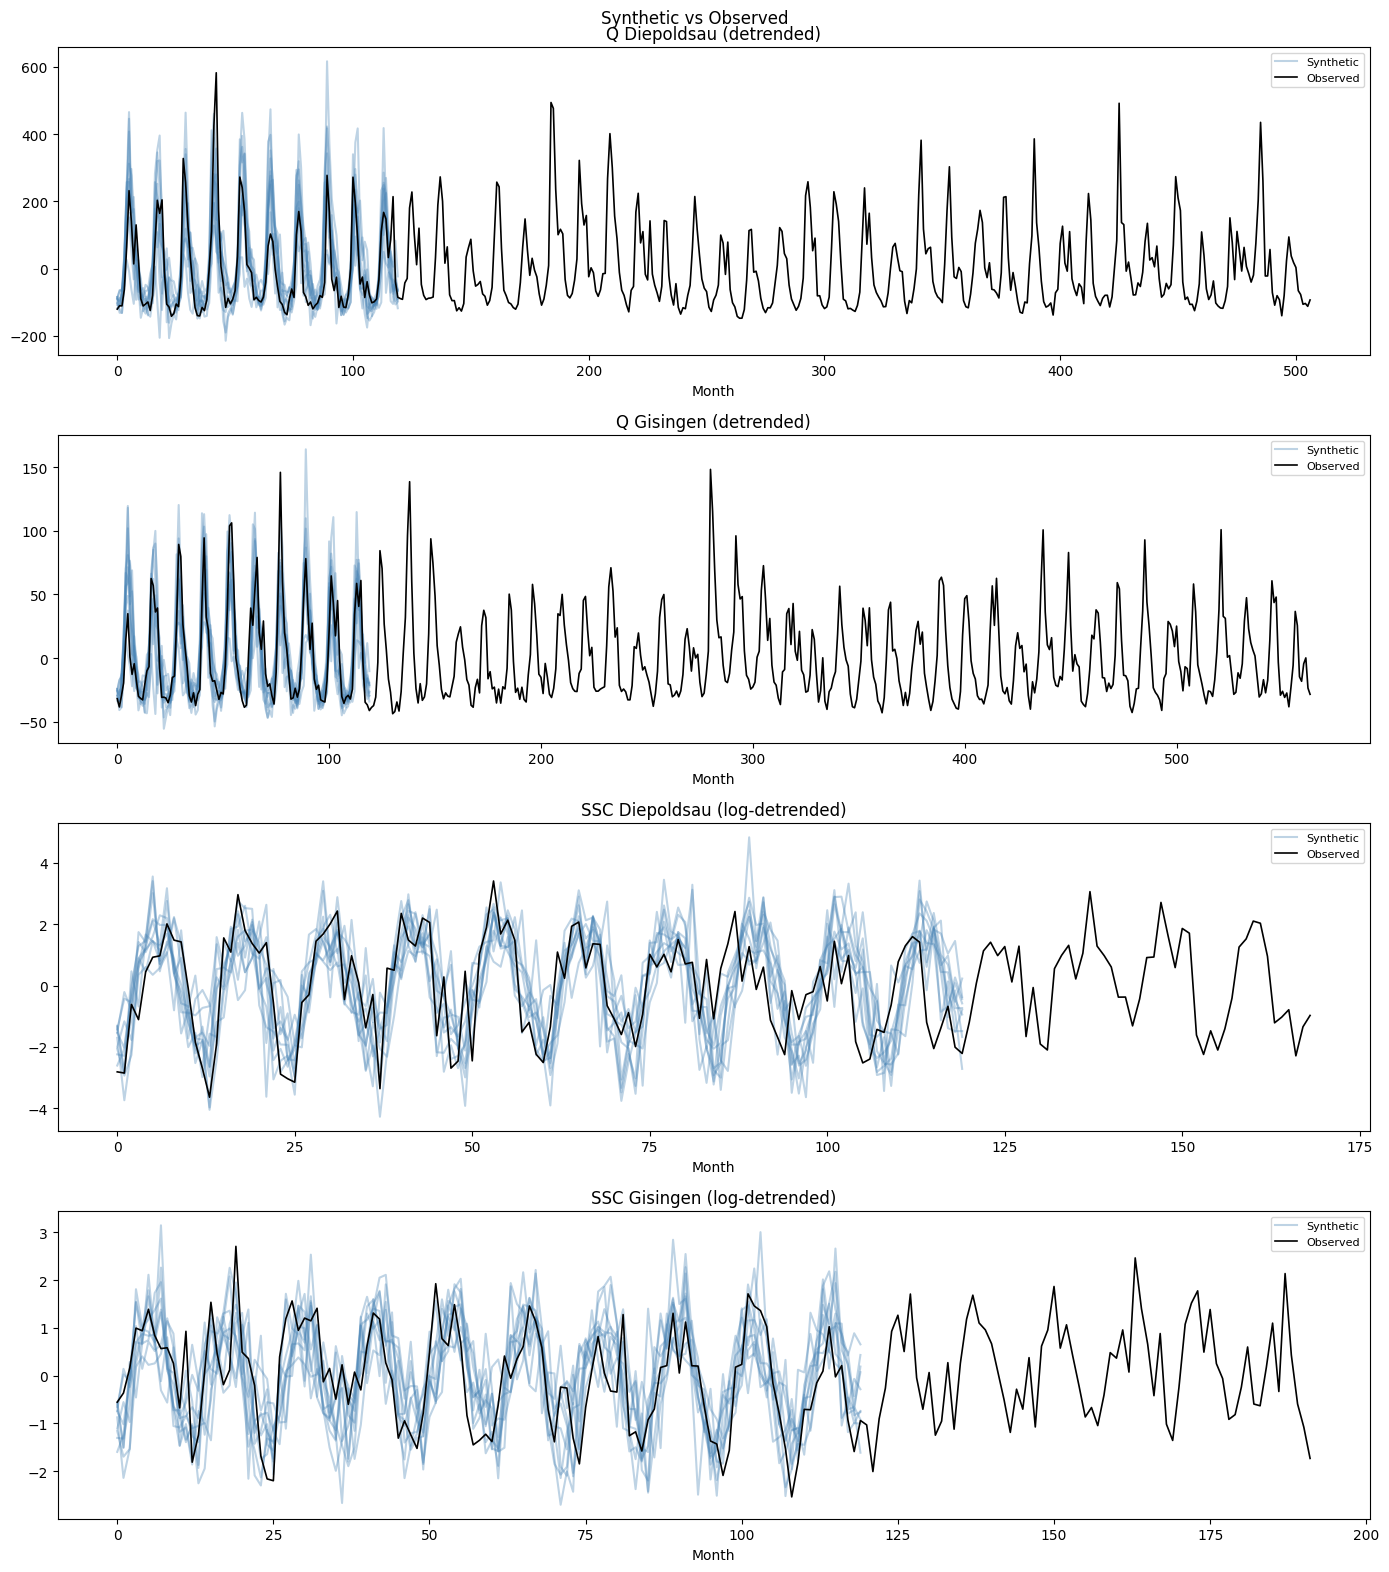

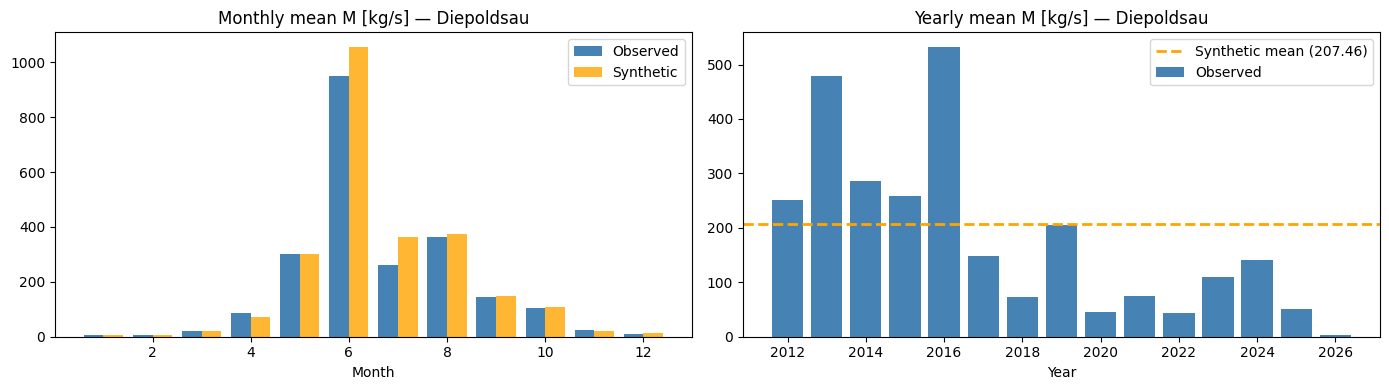

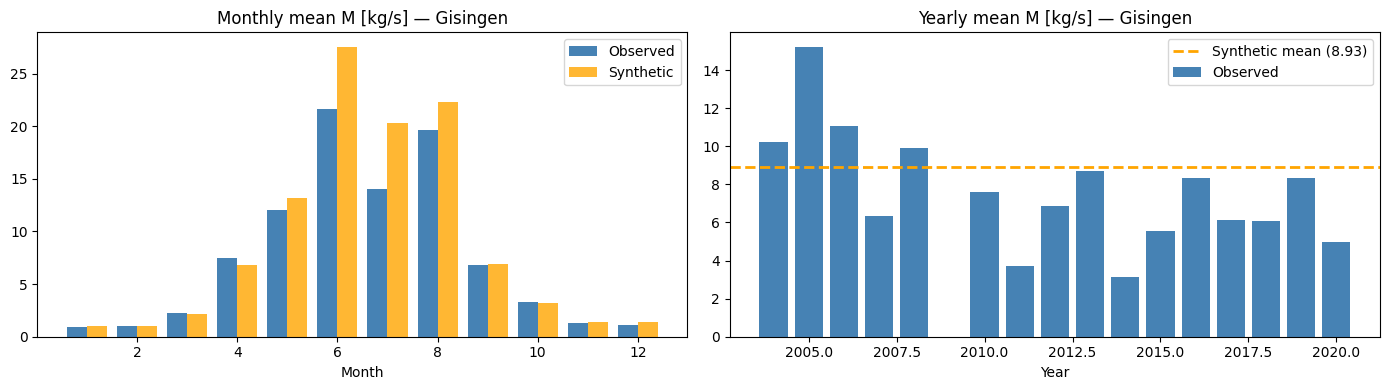

In [12]:
# PLOT
from utils import plot_synthetic_vs_observed, plot_mass_yields

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("Synthetic vs Observed", fontsize=12)
plot_synthetic_vs_observed(q_diep_dt,       sim_q_diep,         title="Q Diepoldsau (detrended)",          ax=axes[0])
plot_synthetic_vs_observed(q_gis_dt,        sim_q_gis,          title="Q Gisingen (detrended)",            ax=axes[1])
plot_synthetic_vs_observed(log_ssc_diep_dt, sim_log_ssc_diep_dt,title="SSC Diepoldsau (log-detrended)",    ax=axes[2])
plot_synthetic_vs_observed(log_ssc_gis_dt,  sim_log_ssc_gis_dt, title="SSC Gisingen (log-detrended)",     ax=axes[3])
plt.tight_layout()

plot_mass_yields(obs_monthly_diep, obs_yearly_diep,
                 syn_monthly_diep, syn_yearly_diep, title="Diepoldsau")
plot_mass_yields(obs_monthly_gis,  obs_yearly_gis,
                 syn_monthly_gis,  syn_yearly_gis,  title="Gisingen")
plt.show()

In [13]:
# PRINT
print("=== Statistical comparison: observed vs synthetic (normalised) ===\n")
for label, df in [("Q Diepoldsau",   stats_q_diep),
                  ("Q Gisingen",     stats_q_gis),
                  ("SSC Diepoldsau", stats_ssc_diep),
                  ("SSC Gisingen",   stats_ssc_gis)]:
    print(f"--- {label} ---")
    print(df.round(4).to_string())
    print()

obs_yearly_mean_diep = obs_yearly_diep.mean()
obs_yearly_mean_gis  = obs_yearly_gis.mean()
ill_fraction = obs_yearly_mean_gis / obs_yearly_mean_diep * 100

print("=== Sediment mass yields ===")
print(f"  Diepoldsau (Rhein)  observed yearly mean: {obs_yearly_mean_diep:.4f} kg/s")
print(f"  Gisingen   (Ill)    observed yearly mean: {obs_yearly_mean_gis:.4f} kg/s")
print(f"  Ill / Rhein contribution:                 {ill_fraction:.1f} %")
print()
print(f"  Diepoldsau synthetic yearly mean: {syn_yearly_diep:.4f} kg/s")
print(f"  Gisingen   synthetic yearly mean: {syn_yearly_gis:.4f} kg/s")

=== Statistical comparison: observed vs synthetic (normalised) ===

--- Q Diepoldsau ---
                   mean       std       min       max
source                                               
observed        -0.0000  123.8363 -147.5894  582.7592
synthetic (all)  7.7056  131.5747 -214.5886  616.8231

--- Q Gisingen ---
                   mean      std      min       max
source                                             
observed         0.0000  34.1513 -43.8198  148.3559
synthetic (all)  1.7145  36.1770 -55.6425  164.1472

--- SSC Diepoldsau ---
                   mean     std     min     max
source                                         
observed         0.0000  1.5741 -3.6426  3.4120
synthetic (all)  0.0298  1.6055 -4.2795  4.8371

--- SSC Gisingen ---
                   mean     std     min     max
source                                         
observed         0.0000  1.0395 -2.5393  2.7089
synthetic (all) -0.0095  1.0431 -2.7037  3.1499

=== Sediment mass yields ===
  Diepo

**Comments — Section 4:**

**Synthetic generation workflow:** AR(3) is used for Q (both AR and ARMA pass Ljung-Box; AR preferred for parsimony and lower AIC at Diepoldsau); ARMA(2,2)/(4,4) is used for log(SSC) (AR fails Ljung-Box → ARMA required; see Section 3). Simulation proceeds on the monthly-standardised residuals. Recomposition: Q residuals are un-standardised (×monthly std + monthly mean); log(SSC) residuals are un-standardised then exponentiated with the log-mean offset to recover physical units.

**Variance reproduction:** The synthetic series reproduce the observed variance closely. For Q: synthetic std is ~6% above observed (131.6 vs 123.8 m³/s at Diepoldsau; 36.2 vs 34.2 m³/s at Gisingen). For log(SSC): the match is very close (synthetic std 2% above observed at Diepoldsau; <0.3% at Gisingen), confirming the log-transform + monthly standardisation pipeline works well. The synthetic Q can slightly exceed the observed historical range (synthetic max 616.8 vs 582.8 m³/s at Diepoldsau), which is expected behaviour from a Gaussian simulator drawing from an unbounded distribution.

**Sediment mass yields:** The observed mean yearly sediment load at Diepoldsau (Rhein) is 180.1 kg/s and at Gisingen (Ill) is 7.6 kg/s, meaning the Ill contributes approximately **4.2%** of the total sediment mass measured at Diepoldsau. The synthetic yearly means are ~15% higher (207.5 kg/s at Diepoldsau; 8.9 kg/s at Gisingen). This positive bias arises from two sources: (1) negative synthetic Q and SSC values are clipped to zero before computing M = Q·C, introducing an asymmetric upward shift; (2) Q and SSC are simulated independently despite being positively correlated (see Section 5), which inflates the expected product M = Q·C relative to the true joint distribution.

**Non-synchronous comparison:** The Q and SSC records at each station do not cover the same period, and the Gisingen and Diepoldsau datasets are not time-synchronised. The 4.2% contribution estimate should therefore be interpreted as a long-term statistical approximation rather than a mass balance at any specific point in time.

# Section 5 — Independent Variables?

In [14]:
# MAIN
from utils import compute_correlation

corr_diep = compute_correlation(q_diep, ssc_diep)
corr_gis  = compute_correlation(q_gis,  ssc_gis)

C:\Users\zehnd\OneDrive\Dokumente\ETH\WRM_2\utils.py:469: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


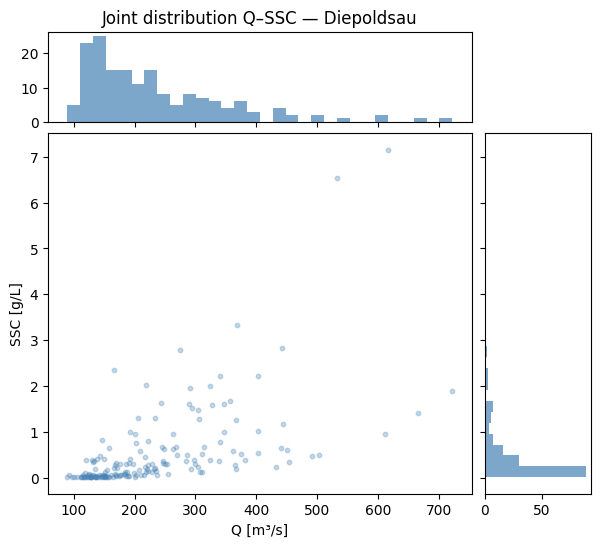

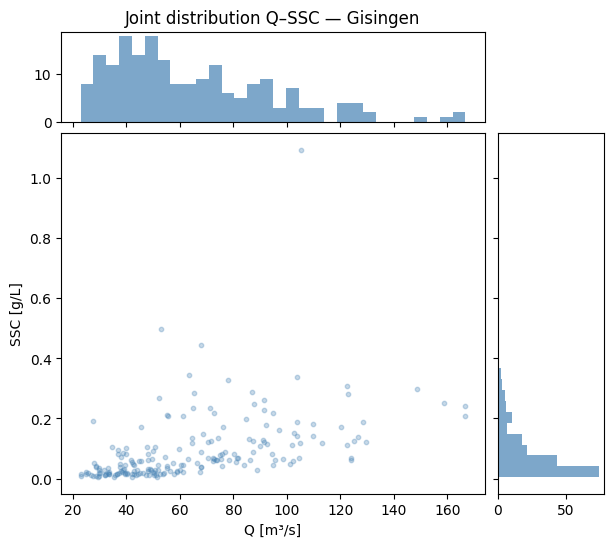

In [15]:
# PLOT
from utils import plot_joint_distribution

plot_joint_distribution(q_diep, ssc_diep, title="Joint distribution Q–SSC — Diepoldsau")
plot_joint_distribution(q_gis,  ssc_gis,  title="Joint distribution Q–SSC — Gisingen")
plt.show()

In [16]:
# PRINT
df5 = pd.DataFrame([
    {"Station": "Diepoldsau", **corr_diep},
    {"Station": "Gisingen",   **corr_gis},
])
df5 = df5.rename(columns={"pearson_r": "Pearson r", "pearson_p": "Pearson p",
                            "spearman_r": "Spearman r", "spearman_p": "Spearman p"})
for col in ["Pearson r", "Pearson p", "Spearman r", "Spearman p"]:
    df5[col] = df5[col].map("{:.4f}".format)
print(df5.to_string(index=False))

   Station Pearson r Pearson p Spearman r Spearman p
Diepoldsau    0.5837    0.0000     0.7381     0.0000
  Gisingen    0.4696    0.0000     0.6762     0.0000


**Comments — Section 5:**

Both Pearson (Diepoldsau: r = 0.58, Gisingen: r = 0.47) and Spearman (Diepoldsau: r = 0.74, Gisingen: r = 0.68) correlations are statistically significant (p ≈ 0) at both stations. Q and C **cannot be considered independent**. The Spearman correlation is substantially higher than Pearson, indicating a non-linear (likely power-law) relationship between Q and C, consistent with a sediment rating curve of the form C = a·Q^b.

**Shortfalls of independent simulation:** Simulating Q and C with separate uncoupled models ignores this dependence. As a consequence: (1) the joint distribution of (Q, C) is not preserved — in particular, high-Q high-C events (which dominate sediment transport) are underrepresented; (2) the computed synthetic mass M = Q·C will have the wrong distribution and likely underestimate peak loads; (3) the estimated Ill contribution based on synthetic data may be biased.

**How to resolve this:** The most physically meaningful approach is a sediment rating curve regression (C = a·Q^b), which directly models the Q–C dependency. Alternatively, a bivariate time series model (e.g. VAR) or a copula-based approach could be used to preserve the joint dependence structure while separately capturing the marginal temporal autocorrelation of each variable.